<a href="https://colab.research.google.com/github/NguyenThai365/pka-google-colab-notebook/blob/main/%5BDeepLearning%5D%2023010531%20Constrastive%20learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Load data**

In [1]:
from tensorflow.keras.datasets.mnist import load_data

(X_train, y_train), (X_test, y_test) = load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


# **Build model CNN**

In [15]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [5]:
inp = Input(shape=(28, 28, 1))
x = Conv2D(filters=8, kernel_size=3, activation='relu')(inp)
x = MaxPooling2D(pool_size=(2, 2))(x)

In [6]:
x = Flatten()(x)
x = Dense(units=32, activation='relu')(x)
x = Dense(units=2)(x)

In [7]:
cnn = Model(inputs=inp, outputs=x)

In [12]:
img1 = Input(shape=(28, 28, 1))
img2 = Input(shape=(28, 28, 1))

In [13]:
f1 = cnn(img1)
f2 = cnn(img2)

In [17]:
from keras import ops
d = ops.sqrt(ops.sum(ops.square(f1 - f2), axis=1, keepdims=True))

In [18]:
model = Model(inputs=[img1, img2], outputs=d)
model.summary()
cnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 2)         │     43,442 │ input_layer_6[0]… │
│ (Functional)        │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_3          │ (None, 2)         │          0 │ functional[2][0], │
│ (Subtract)          │                   │            │ functional[3][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ square (Square)     │ (None, 2)         │          0 │ subtract_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum (Sum)           │ (None, 1)         │          0 │ square[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sqrt (Sqrt)         │ (None, 1)         │          0 │ sum[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,442 (169.70 KB)

 Trainable params: 43,442 (169.70 KB)

 Non-trainable params: 0 (0.00 B)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        43,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,442 (169.70 KB)

 Trainable params: 43,442 (169.70 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
def loss(y_true, y_pred):
  proba = K.exp(-K.square(y_pred))
  return -K.mean(y_true * K.log(proba) + (1-y_true) * K.log(1-proba))

In [21]:
def loss1(y_true, y_pred):
  return K.mean(y_true * K.square(y_pred) + (1-y_true) * K.square(K.maximum(1.0 - y_pred, 0)))

In [22]:
model.compile(optimizer='adam', loss=loss1)

# **Make all pairs or other strategies; some innovation here**

In [24]:
import numpy as np
from matplotlib import pyplot as plt

In [31]:
def generator(X, y, k=8):
  unique_labels = np.unique(y)
  while True:
    X1 = []
    X2 = []
    y_batch = []
    for label in unique_labels:
      label_idx = np.where(y == label)[0]
      other_labels = set(unique_labels) - {label}
      for i in range(k):
        i1 = np.random.choice(label_idx)
        i2 = np.random.choice(label_idx)
        while i1 == i2:
          i2 = np.random.choice(label_idx)
        X1.append(X[i1][:, :, None])
        X2.append(X[i2][:, :, None])
        y_batch.append([1.0])

        i1 = np.random.choice(label_idx)
        my_label = np.random.choice(list(other_labels))
        i2 = np.random.choice(list(np.where(y == my_label)[0]))
        X1.append(X[i1][:, :, None])
        X2.append(X[i2][:, :, None])
        y_batch.append([0.0])
    # yield [np.array(X1) / 255., np.array(X2) / 255.], np.array(y_batch)
    yield (np.array(X1) / 255., np.array(X2) / 255.), np.array(y_batch)

Batch size: 160
(28, 28, 1)
Pair label: [0.]


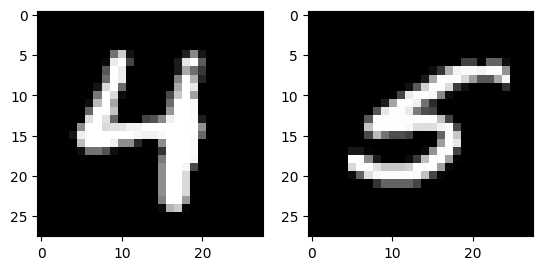

In [32]:
for pair, y in generator(X_test, y_test):
  print('Batch size:', len(y))
  idx = np.random.choice(range(len(y)))
  print(pair[0][idx].shape)
  print('Pair label:', y[idx])
  plt.subplot(121)
  plt.imshow(pair[0][idx].reshape(28, 28), cmap='gray')
  plt.subplot(122)
  plt.imshow(pair[1][idx].reshape(28, 28), cmap='gray')
  break

# **Fit model**

In [33]:
history = model.fit(generator(X_train, y_train, k=32),
                    steps_per_epoch=5,
                    epochs=500,
                    validation_data=generator(X_test, y_test, k=8),
                    validation_steps=5)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 730ms/step - loss: 0.2800 - val_loss: 0.2104
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 633ms/step - loss: 0.2035 - val_loss: 0.1948
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.1800 - val_loss: 0.1708
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 592ms/step - loss: 0.1654 - val_loss: 0.1755
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 656ms/step - loss: 0.1600 - val_loss: 0.1572
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 648ms/step - loss: 0.1478 - val_loss: 0.1414
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.1459 - val_loss: 0.1385
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 560ms/step - loss: 0.1371 - val_loss: 0.1369
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 615ms/step - loss: 0.1370 - val_loss: 0.1318
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 674ms/step - loss: 0.1256 - val_loss: 0.1280
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 811ms/step - loss: 0.1282 - val_loss: 0.1194
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 677ms/step - loss: 0.1255 - 

# **Visualize learning process**

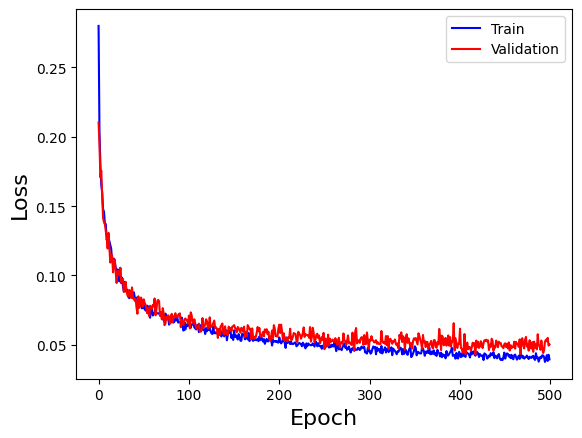

In [34]:
plt.plot(history.history['loss'], label='Train', c='b')
plt.plot(history.history['val_loss'], label='Validation', c='r')
plt.legend()
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step 
Batch size: 160
Pair label: [0.]
Distance: [1.4078294]
Distance by feature: [1.407829]


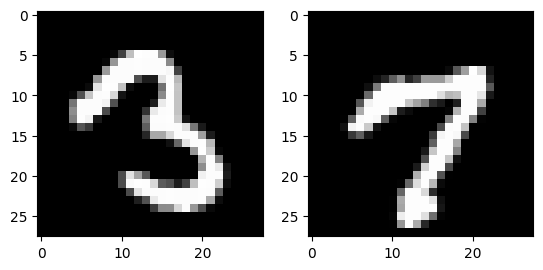

In [35]:
for pair, y in generator(X_test, y_test):
  y_pred = model.predict(pair)
  print('Batch size:', len(y))
  idx = np.random.choice(range(len(y)))
  print('Pair label:', y[idx])
  print('Distance:', y_pred[idx])

  f1 = cnn(pair[0])
  f2 = cnn(pair[1])
  d = np.sqrt(np.sum((f1-f2)**2, axis=1, keepdims=True))
  print('Distance by feature:', d[idx])

  plt.subplot(121)
  plt.imshow(pair[0][idx].reshape(28, 28), cmap='gray')
  plt.subplot(122)
  plt.imshow(pair[1][idx].reshape(28, 28), cmap='gray')
  break

# **Visualize new feature space**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


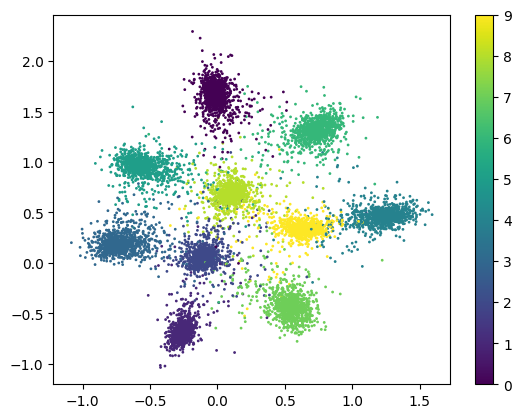

In [36]:
f = cnn.predict(X_test/255.)
p = plt.scatter(f[:, 0], f[:, 1], c=y_test, s=1)
plt.colorbar(p)

# **Save model**

In [37]:
cnn.save('cnn_loss1.h5')

# **Load model and test**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


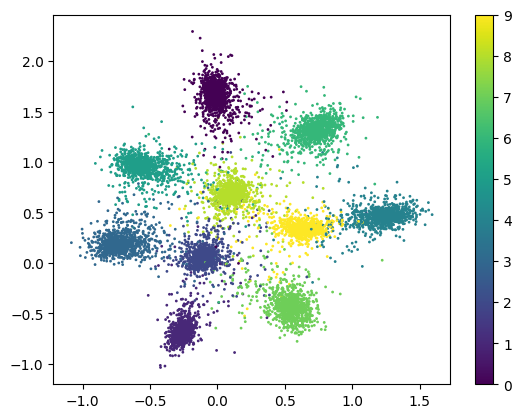

In [38]:
from tensorflow.keras.models import load_model
m = load_model('cnn_loss1.h5')
f1 = m.predict(X_test/255.)
p = plt.scatter(f1[:, 0], f1[:, 1], c=y_test, s=1)
plt.colorbar(p)

# **Visualize negative distance and positive distance**

In [39]:
i = 0
y_true = []
y_pred = []
for pair, y in generator(X_test, y_test):
  f1 = cnn(pair[0])
  f2 = cnn(pair[1])
  d = np.sqrt(np.sum((f1-f2)**2, axis=1, keepdims=True))
  y_pred += list(d.ravel())
  y_true += list(y)
  i += 1
  if i > 500:
    break

# ́**Plot histogram**

(array([8.51988622e-03, 3.13531845e-02, 8.38356889e-02, 2.51507016e-01,
        6.23655608e-01, 9.23385550e-01, 8.40401149e-01, 6.28767539e-01,
        5.37434368e-01, 6.53475206e-01, 5.56348513e-01, 5.13579107e-01,
        4.34684551e-01, 2.79111671e-01, 1.76702278e-01, 1.54550846e-01,
        9.42300087e-02, 3.25459355e-02, 4.94153753e-03, 5.11192705e-04]),
 array([0.01192768, 0.15835041, 0.30477312, 0.45119584, 0.59761858,
        0.74404132, 0.89046401, 1.03688681, 1.18330956, 1.3297323 ,
        1.47615504, 1.62257779, 1.76900041, 1.91542315, 2.06184578,
        2.20826864, 2.35469127, 2.50111389, 2.64753675, 2.79395938,
        2.94038224]),
 <BarContainer object of 20 artists>)

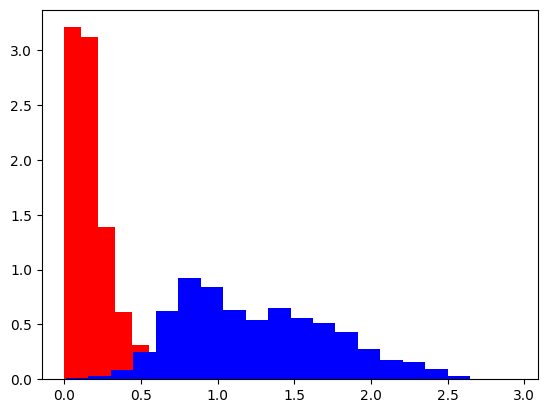

In [41]:
y_pred = np.array(y_pred)
y_true = np.array(y_true).ravel()

positive_distances = y_pred[y_true == 1]
negative_distances = y_pred[y_true == 0]

plt.hist(positive_distances, color='r', density=True, bins=20)
plt.hist(negative_distances, color='b', density=True, bins=20)

# **Check report using sklearn**

In [45]:
thresh = 0.5
y_pred_ = (y_pred < thresh)
y_pred_.astype('uint8')
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_))

              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96     40080
         1.0       0.97      0.95      0.96     40080

    accuracy                           0.96     80160
   macro avg       0.96      0.96      0.96     80160
weighted avg       0.96      0.96      0.96     80160

